In [1]:
print("Hello")

Hello


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [178]:
class AgentState(TypedDict):
    n1:int
    n2:int
    operation:str
    final:int
    

In [179]:
def adder(state:AgentState)->AgentState:
    """This node is will do addition"""
    state["final"]=state['n1']+state['n2']
    return state

def sub(state:AgentState)->AgentState:
    """This node will do subtraction"""
    state["final"]=state['n1']-state['n2']
    return state

def decide_node(state: AgentState)->AgentState:
    """This node will select the next phase of the graph"""
    if state['operation']=="+":
        return "addition_operation" #here we will retun the edge rigth now we keep it as addition_operation now 
    elif state['operation']=='-':
        return "sub_operation"
    
    
def div(state:AgentState)->AgentState:
    """This node will do the division"""
    state["final"]=state['n1']/state['n2']
    return state

In [180]:
g1=StateGraph(AgentState)
g1.add_node("Add",adder)
g1.add_node("sub",sub)
g1.add_node("router",lambda state: state) #normally this not work cause in add and sub function we return an state but over decide_node doesnot return an state it return an edge so we need to change the code to this->lambda state:state

g1.add_edge(START,'router')
g1.add_conditional_edges(
     "router", #source
     decide_node, #path
    #path Map in form of dict{}
    {
        #Edge:Node format
        "addition_operation":"Add",
        "sub_operation":"sub"
    }
)
g1.add_edge("Add",END)
g1.add_edge("sub",END)
app=g1.compile()

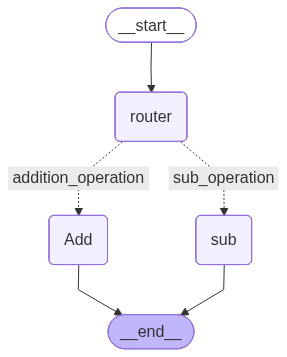

In [181]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [182]:
Initial_state=AgentState(n1=10,operation="-",n2=5)
print(app.invoke(Initial_state))


{'n1': 10, 'n2': 5, 'operation': '-', 'final': 5}


In [8]:
res=app.invoke({"n1":10,"n2":5,"operation":"+"})


In [9]:
print(res)

{'n1': 10, 'n2': 5, 'operation': '+'}


In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class AgentState(TypedDict):
    n1: int
    n2: int
    operation: str
    final: int


def adder(state: AgentState) -> AgentState:
    state["final"] = state["n1"] + state["n2"]
    return state


def sub(state: AgentState) -> AgentState:
    state["final"] = state["n1"] - state["n2"]
    return state


def decide_node(state: AgentState):
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "sub_operation"


g1 = StateGraph(AgentState)

g1.add_node("Add", adder)
g1.add_node("sub", sub)
g1.add_node("router", lambda state: state)

g1.add_edge(START, "router")

g1.add_conditional_edges(
    "router",
    decide_node,
    {
        "addition_operation": "Add",
        "sub_operation": "sub"
    }
)

g1.add_edge("Add", END)
g1.add_edge("sub", END)

app = g1.compile()

result = app.invoke({
    "n1": 10,
    "n2": 5,
    "operation": "+"
})

print(result)

{'n1': 10, 'n2': 5, 'operation': '+', 'final': 15}


In [24]:
class AgentState:
    number1:int
    number2:int
    number3:int
    number4:int
    op1:str
    op2:str
    res1:str
    res2:str

In [25]:
def addnode(state:AgentState)->AgentState:
    """This is the first node to do add operation"""
    state["res1"]=state['number1']+state['number2']
    return state

def subnode(state:AgentState)->AgentState:
    """This is the first node to do the sub operation"""
    state["res1"]=state['number1']-state['number2']
    return state

def addnode2(state: AgentState)->AgentState:
    """This is the third node to add operation"""
    state["res2"]=state['number3']+state['number4']
    return state

def subnode2(state:AgentState)->AgentState:
    """This is the 4th node to do sub operation"""
    state["res2"]=state['number3']-state['number4']
    return state
    
def decide_node(state:AgentState)->AgentState:
    if state["op1"]=="+":
        return "add_operation1"
    elif state["op1"]=="-":
        return "sub_operation1"
    
    
def decide_node2(state:AgentState)->AgentState:
    if state["op2"]=="+":
        return "add_operation2"
    elif state["op2"]=="-":
        return "sub_operation2"
    
    

In [26]:
g2=StateGraph(AgentState)
g2.add_node("Add1",addnode)
g2.add_node("SUB1",subnode)
g2.add_node("ADD2",addnode2)
g2.add_node("SUB2",subnode2)
g2.add_node("Router1",lambda state: state)
g2.add_node('Router2',lambda state: state)
g2.add_edge(START,"Router1")
g2.add_conditional_edges(
    "Router1",
    decide_node,
    {
        "add_operation1":"Add1",
        "sub_operation1":"SUB1"
    } 
)
g2.add_conditional_edges(
    "Router2",
    decide_node2,
    {
        "add_operation2":"ADD2",
        "sub_operation2":"SUB2"
    }
)
g2.add_edge("Add1",'Router2')
g2.add_edge("SUB1",'Router2')
g2.add_edge("ADD2",END)
g2.add_edge("SUB2",END)
appp2=g2.compile()

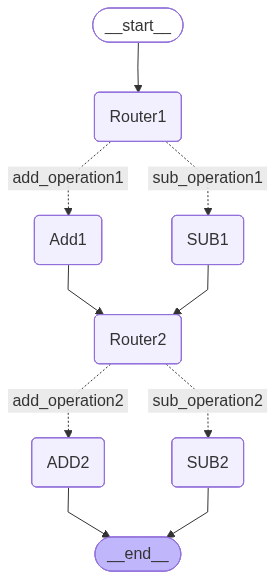

In [22]:
from IPython.display import Image,display

display(Image(appp2.get_graph().draw_mermaid_png()))

In [184]:
initial_state = {
    "number1": 10,
    "number2": 5,
    "number3": 4,
    "number4": 2,
    "op1": "-",
    "op2": "+",
    "res1": 0,
    "res2":0
}

result = appp2.invoke(initial_state)

print(result)

{'number1': 10, 'number2': 5, 'number3': 4, 'number4': 2, 'op1': '-', 'op2': '+', 'res1': 5, 'res2': 6}


In [44]:
class AgentState(TypedDict):
    n1:int
    n2:int
    n3:int
    n4:int
    op1:str
    op2:str
    ans1:int
    ans2:int
    

In [69]:
def adder(state:AgentState)->AgentState:
    """This is the add-operation"""
    state["ans1"]=state["n1"]+state["n2"]
    return state

def subtrac(state:AgentState)->AgentState:
    """This is the 2nd operation of the node"""
    state["ans1"]=state["n1"]-state["n2"]
    return state

def adder2(state: AgentState)->AgentState:
    """This is the third node of the adder2"""
    state["ans2"]=state["n3"]+state["n4"]
    return state

def subb2(state:AgentState)->AgentState:
    """This is the last node for sub"""
    state["ans2"]=state["n3"]-state["n4"]
    return state

def dec1(state: AgentState)->str:
    if state["op1"]=="+":  
      return "add_op1"
    elif state["op1"]=="-":
        return "sub_op1"

def dec2(state:AgentState)->str:
    if state["op2"]=="+":
        return "add_op2"
    elif state["op2"]=="-":
        return "sub_op2"
    

In [70]:
g4=StateGraph(AgentState)
g4.add_node("Add",adder)
g4.add_node("Sub",subtrac)
g4.add_node("Add2",adder2)
g4.add_node("Sub2",subb2)
g4.add_node("Router1",lambda state: state)# created node "Router1"
g4.add_node("Router2",lambda state: state)
g4.add_edge(START,"Router1")#must also be connected so no same format as that one 
g4.add_conditional_edges(
    "Router1",
    dec1,
    {
        "add_op1":"Add",
        "sub_op1":"Sub"
    }
)
g4.add_conditional_edges(
    "Router2",
    dec2,
    {
     "add_op2":"Add2",
     "sub_op2":"Sub2"  
    }
)
g4.add_edge("Add","Router2")
g4.add_edge("Sub","Router2")
g4.add_edge("Add2",END)
g4.add_edge("Sub2",END)
ark=g4.compile()



In [57]:
initial_s1={

    "n1":20,
    "n2":15,
    "n3":10,
    "n4":5,
    "op1":"+",
    "op2":"-",
    "ans1":0,
    "ans2":0
}

In [58]:
res1=ark.invoke(initial_s1)


In [59]:
print(res1)

{'n1': 20, 'n2': 15, 'n3': 10, 'n4': 5, 'op1': '+', 'op2': '-', 'ans1': 35, 'ans2': 5}


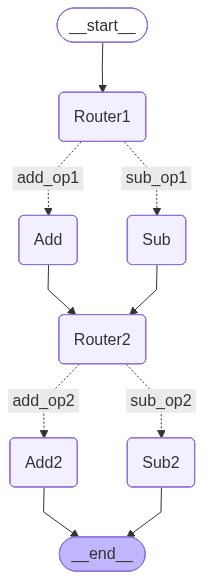

In [60]:
from IPython.display import Image,display

display(Image(ark.get_graph().draw_mermaid_png()))

In [61]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [170]:
class AgentState(TypedDict):
    k1:int
    k2:int
    k3:int
    k4:int
    op1:str
    op2:str
    
    fans1:int
    fans2:int

In [171]:
def addm(state:AgentState)->AgentState:
    """This is the first add node that do addition"""
    state["fans1"]=state["k1"]+state["k2"]
    return state

def subm(state:AgentState)->AgentState:
    """This is the second node that do the subtraction"""
    state["fans1"]=state["k1"]-state["k2"]
    return state

def mul(state:AgentState)->AgentState:
    """This is the first add node that do addition"""
    state["fans1"]=state["k1"]*state["k2"]
    return state

def div(state:AgentState)->AgentState:
    """This is the second node that do the subtraction"""
    state["fans1"]=state["k1"]/state["k2"]
    return state

def addm2(state:AgentState)->AgentState:
    """This is the third node that does the 2nd operation adding"""
    state["fans2"]=state["k3"]+state["k4"]
    return state

def subm2(state:AgentState)->AgentState:
   """This is the final node that does the operation"""
   state["fans2"]=state["k3"]-state["k4"]
   return state

def mul2(state:AgentState)->AgentState:
    """This is the first add node that do addition"""
    state["fans2"]=state["k3"]*state["k4"]
    return state

def div2(state:AgentState)->AgentState:
    """This is the second node that do the subtraction"""
    state["fans2"]=state["k3"]/state["k4"]
    return state

def decm1(state:AgentState)->str:
    if state["op1"]=="+":
        return "addm_ope1"
    elif state["op1"]=="-":
        return "sub_opm1"
    elif state["op1"]=="*":
        return "mul_opm1"
    elif state["op1"]=="/":
        return "div_opm1"
    
def decm2(state:AgentState)->str:
    if state["op2"]=="+":
            return "addm_op2"
    elif state["op2"]=="-":
            return "sub_op2"
    elif state["op2"]=="*":
            return "mul_opm2"
    elif state["op2"]=="/":
            return "div_opm2"
     
    
    

In [172]:
g5=StateGraph(AgentState)
g5.add_node("adders",addm)
g5.add_node("subers",subm)
g5.add_node("adder2",addm2)
g5.add_node("subber2",subm2)
g5.add_node("mul1",mul)
g5.add_node("div1",div)
g5.add_node("mul2",mul2)
g5.add_node("div2",div2)


g5.add_node("Router1",lambda state: state)
g5.add_node("Router2",lambda state:state)
g5.add_edge(START,"Router1")
g5.add_conditional_edges(
    "Router1",
    decm1,{
        "addm_ope1":"adders",
        "sub_opm1":"subers",
        "mul_opm1":"mul1",
        "div_opm1":"div1"
    }
)
g5.add_conditional_edges(
    "Router2",
    decm2,
    {
      "addm_op2":"adder2",
      "sub_op2":"subber2", #here the name must be the same so we have to give the same name 
      "mul_opm2":"mul2",
      "div_opm2":"div2"
    }
)
g5.add_edge("adders","Router2")
g5.add_edge("subers","Router2")
g5.add_edge("mul1","Router2")
g5.add_edge("div1","Router2")
g5.add_edge("adder2",END)
g5.add_edge("subber2",END)
g5.add_edge("mul2",END)
g5.add_edge("div2",END)
dark=g5.compile()

    

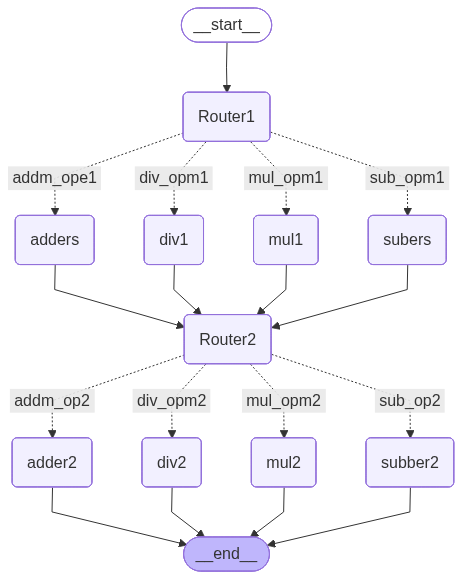

In [173]:
from IPython.display import Image,display

display(Image(dark.get_graph().draw_mermaid_png()))

In [174]:
initial_s2={
    "k1":2,
    "k2":1,
    "k3":2,
    "k4":3,
    "op1":"*",
    "op2":"+",
    "fans1":0,
    "fans2":0
}

In [175]:
resullt=dark.invoke(initial_s2)

In [177]:
print(resullt)

{'k1': 2, 'k2': 1, 'k3': 2, 'k4': 3, 'op1': '*', 'op2': '+', 'fans1': 2, 'fans2': 5}
